# E-Commerce Revenue, Customer & Operations Analytics

**Author:** Vedant Bhavsar  
**Dataset:** Brazilian E-Commerce (Olist) - ~99K orders, Sep 2016 - Oct 2018  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

---

## 1. Business Problem

An e-commerce marketplace wants to understand:
- Revenue performance and growth trends
- Customer behavior and repeat purchasing patterns
- Product/category performance
- Delivery performance and its impact on customer satisfaction
- Customer value segmentation (RFM)

**Objective:** Identify measurable business patterns and translate them into actionable recommendations.

## 2. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Setup complete')

Setup complete


## 3. Data Loading

Loading the Olist Brazilian E-Commerce dataset (8 tables, ~99K orders).

In [2]:
import os
DATA_PATH = '../data/raw/' if os.path.exists('../data/raw/') else 'data/raw/'

customers = pd.read_csv(os.path.join(DATA_PATH, 'olist_customers_dataset.csv'))
orders = pd.read_csv(os.path.join(DATA_PATH, 'olist_orders_dataset.csv'))
order_items = pd.read_csv(os.path.join(DATA_PATH, 'olist_order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(DATA_PATH, 'olist_order_payments_dataset.csv'))
reviews = pd.read_csv(os.path.join(DATA_PATH, 'olist_order_reviews_dataset.csv'))
products = pd.read_csv(os.path.join(DATA_PATH, 'olist_products_dataset.csv'))
sellers = pd.read_csv(os.path.join(DATA_PATH, 'olist_sellers_dataset.csv'))
categories = pd.read_csv(os.path.join(DATA_PATH, 'product_category_name_translation.csv'))

datasets = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'categories': categories
}

for name, df in datasets.items():
    print(f'{name:15s} -> {df.shape[0]:>8,} rows x {df.shape[1]} cols')

customers       ->   99,441 rows x 5 cols
orders          ->   99,441 rows x 8 cols
order_items     ->  112,650 rows x 7 cols
payments        ->  103,886 rows x 5 cols
reviews         ->   99,224 rows x 7 cols
products        ->   32,951 rows x 9 cols
sellers         ->    3,095 rows x 4 cols
categories      ->       71 rows x 2 cols


## 4. Data Quality Checks

**Question:** Is the data complete and consistent?  
**Approach:** Check nulls, duplicates, data types, and value distributions.

In [3]:
# Null counts for each table
print('=== NULL COUNTS PER TABLE ===')
for name, df in datasets.items():
    null_pct = (df.isnull().sum() / len(df) * 100).round(2)
    non_zero = null_pct[null_pct > 0]
    if len(non_zero) > 0:
        print(f'\n{name}:')
        for col, pct in non_zero.items():
            print(f'  {col}: {pct}% null')
    else:
        print(f'\n{name}: No nulls')

=== NULL COUNTS PER TABLE ===

customers: No nulls

orders:
  order_approved_at: 0.16% null
  order_delivered_carrier_date: 1.79% null
  order_delivered_customer_date: 2.98% null

order_items: No nulls

payments: No nulls

reviews:
  review_comment_title: 88.34% null
  review_comment_message: 58.7% null

products:
  product_category_name: 1.85% null
  product_name_lenght: 1.85% null
  product_description_lenght: 1.85% null
  product_photos_qty: 1.85% null
  product_weight_g: 0.01% null
  product_length_cm: 0.01% null
  product_height_cm: 0.01% null
  product_width_cm: 0.01% null

sellers: No nulls

categories: No nulls


In [4]:
# Check for duplicate order_ids in orders table
# Orders should have one row per order_id
dup_orders = orders['order_id'].duplicated().sum()
print(f'Duplicate order_ids in orders table: {dup_orders}')

# Check order status distribution
print('\n=== ORDER STATUS DISTRIBUTION ===')
status_dist = orders['order_status'].value_counts()
for status, count in status_dist.items():
    pct = round(100 * count / len(orders), 2)
    print(f'  {status}: {count:,} ({pct}%)')

Duplicate order_ids in orders table: 0

=== ORDER STATUS DISTRIBUTION ===
  delivered: 96,478 (97.02%)
  shipped: 1,107 (1.11%)
  canceled: 625 (0.63%)
  unavailable: 609 (0.61%)
  invoiced: 314 (0.32%)
  processing: 301 (0.3%)
  created: 5 (0.01%)
  approved: 2 (0.0%)


## 5. Data Cleaning & Feature Engineering

**Steps:**
1. Convert date columns to datetime
2. Filter to delivered orders for revenue analysis
3. Merge category translation for English names
4. Calculate delivery metrics (delivery_days, is_late)

In [5]:
# Convert date columns to datetime
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Filter to delivered orders only (for accurate revenue analysis)
delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f'Total orders: {len(orders):,}')
print(f'Delivered orders: {len(delivered):,} ({round(100*len(delivered)/len(orders),1)}%)')

Total orders: 99,441
Delivered orders: 96,478 (97.0%)


In [6]:
# Merge products with English category names
products_en = products.merge(categories, on='product_category_name', how='left')
products_en['category'] = products_en['product_category_name_english'].fillna(
    products_en['product_category_name'])

# Build main analytical dataframe
# Join: orders -> order_items -> products -> customers
df = (delivered
    .merge(order_items, on='order_id')
    .merge(products_en[['product_id', 'category']], on='product_id', how='left')
    .merge(customers, on='customer_id')
)

print(f'Analytical dataframe: {len(df):,} rows x {df.shape[1]} cols')

Analytical dataframe: 110,197 rows x 19 cols


In [7]:
# Feature Engineering: Delivery Metrics
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

df['estimated_days'] = (
    df['order_estimated_delivery_date'] - df['order_purchase_timestamp']
).dt.days

df['is_late'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)

# Extract month for trend analysis
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

print('Delivery metrics created:')
print(f'  Avg delivery days: {df["delivery_days"].mean():.1f}')
print(f'  Late delivery %: {df["is_late"].mean()*100:.1f}%')

Delivery metrics created:
  Avg delivery days: 12.0
  Late delivery %: 7.9%


## 6. Exploratory Data Analysis - Revenue

**Question:** What is the revenue trend, and what drives it?

In [8]:
# Headline KPIs
total_revenue = df['price'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_unique_id'].nunique()
aov = df.groupby('order_id')['price'].sum().mean()

print('=== REVENUE KPIs ===')
print(f'Total Revenue:    R$ {total_revenue:,.2f}')
print(f'Total Orders:     {total_orders:,}')
print(f'Total Customers:  {total_customers:,}')
print(f'Avg Order Value:  R$ {aov:,.2f}')

=== REVENUE KPIs ===
Total Revenue:    R$ 13,221,498.11
Total Orders:     96,478
Total Customers:  93,358
Avg Order Value:  R$ 137.04


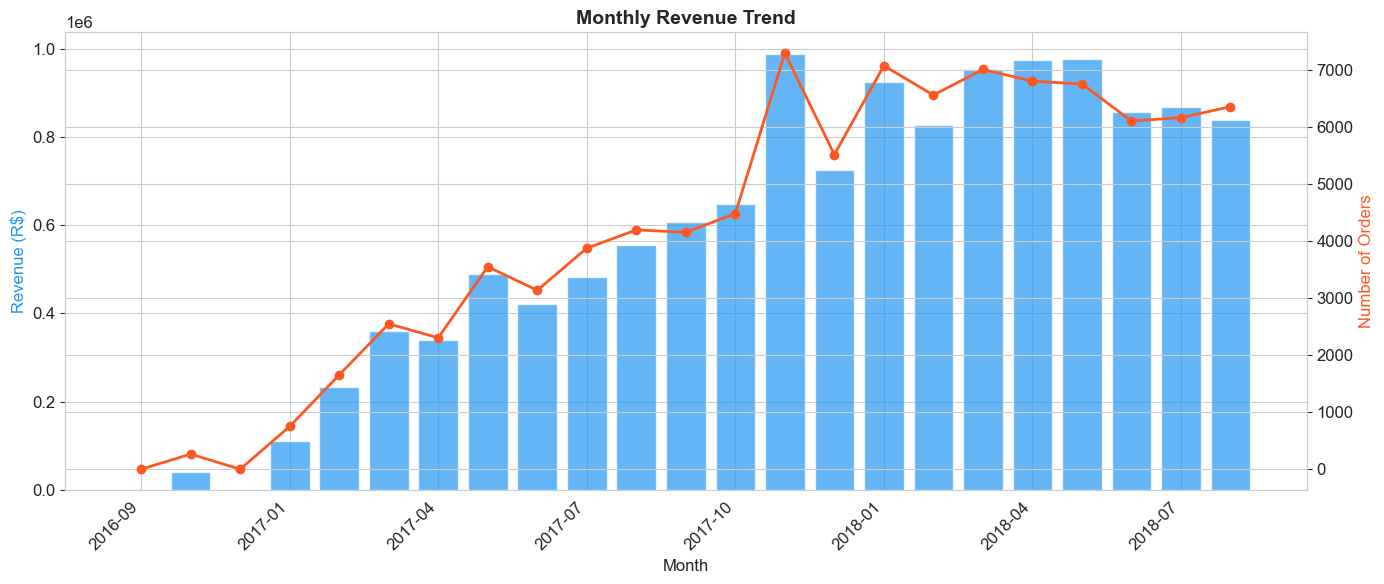


Peak revenue month: 2017-11
Peak revenue: R$ 987,765.37


In [9]:
# Monthly Revenue Trend
monthly = df.groupby('order_month').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()

monthly['order_month'] = monthly['order_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#2196F3'
ax1.bar(range(len(monthly)), monthly['revenue'], color=color1, alpha=0.7, label='Revenue')
ax1.set_ylabel('Revenue (R$)', color=color1, fontsize=12)
ax1.set_xlabel('Month')
ax1.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')

# Set x-tick labels (show every 3rd month for readability)
ax1.set_xticks(range(0, len(monthly), 3))
ax1.set_xticklabels(monthly['order_month'].iloc[::3], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['orders'], color='#FF5722', marker='o',
         linewidth=2, label='Orders')
ax2.set_ylabel('Number of Orders', color='#FF5722', fontsize=12)

fig.tight_layout()
plt.show()

print(f'\nPeak revenue month: {monthly.loc[monthly["revenue"].idxmax(), "order_month"]}')
print(f'Peak revenue: R$ {monthly["revenue"].max():,.2f}')

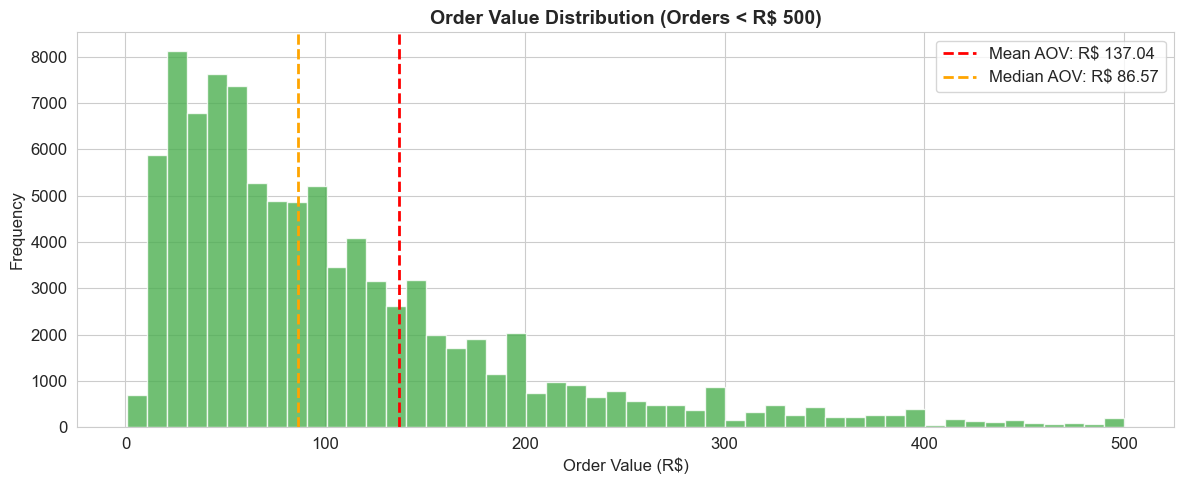

Mean AOV: R$ 137.04
Median AOV: R$ 86.57
Std Dev: R$ 209.05


In [10]:
# AOV Distribution
order_values = df.groupby('order_id')['price'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(order_values[order_values < 500], bins=50, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.axvline(order_values.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean AOV: R$ {order_values.mean():.2f}')
ax.axvline(order_values.median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median AOV: R$ {order_values.median():.2f}')
ax.set_xlabel('Order Value (R$)')
ax.set_ylabel('Frequency')
ax.set_title('Order Value Distribution (Orders < R$ 500)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean AOV: R$ {order_values.mean():.2f}')
print(f'Median AOV: R$ {order_values.median():.2f}')
print(f'Std Dev: R$ {order_values.std():.2f}')

## 7. Customer Analysis

**Question:** What is the repeat customer rate, and how much revenue do repeat customers contribute?

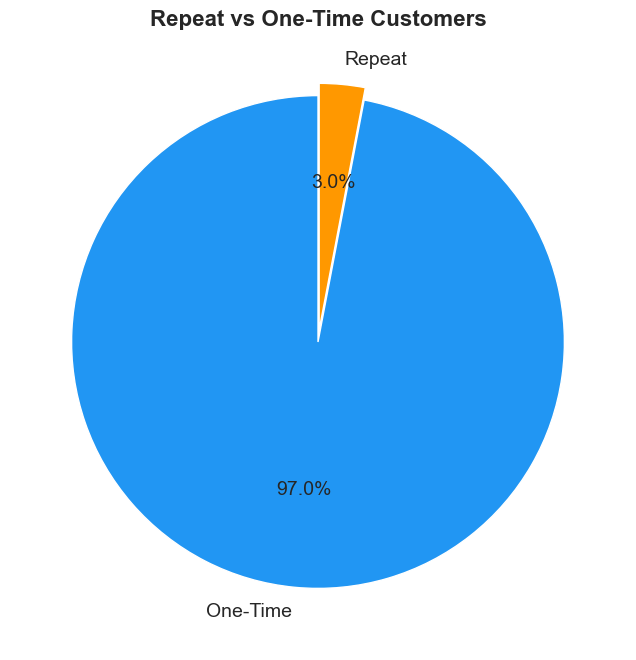

Total unique customers: 93,358
One-time customers: 90,557
Repeat customers: 2,801 (3.0%)


In [11]:
# Repeat vs One-Time Customers
cust_orders = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
cust_orders.columns = ['customer_unique_id', 'order_count']
cust_orders['customer_type'] = np.where(cust_orders['order_count'] > 1, 'Repeat', 'One-Time')

type_counts = cust_orders['customer_type'].value_counts()
repeat_pct = round(100 * type_counts.get('Repeat', 0) / len(cust_orders), 2)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#2196F3', '#FF9800']
ax.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90, textprops={'fontsize': 14},
       explode=[0, 0.05])
ax.set_title('Repeat vs One-Time Customers', fontsize=16, fontweight='bold')
plt.show()

print(f'Total unique customers: {len(cust_orders):,}')
print(f'One-time customers: {type_counts.get("One-Time", 0):,}')
print(f'Repeat customers: {type_counts.get("Repeat", 0):,} ({repeat_pct}%)')

In [12]:
# Revenue Contribution: Repeat vs One-Time
cust_revenue = df.groupby('customer_unique_id').agg(
    order_count=('order_id', 'nunique'),
    total_spend=('price', 'sum')
).reset_index()

cust_revenue['customer_type'] = np.where(cust_revenue['order_count'] > 1, 'Repeat', 'One-Time')

rev_by_type = cust_revenue.groupby('customer_type')['total_spend'].agg(['sum', 'mean', 'count'])
rev_by_type['revenue_share'] = (rev_by_type['sum'] / rev_by_type['sum'].sum() * 100).round(2)

print('=== REVENUE BY CUSTOMER TYPE ===')
print(rev_by_type.to_string())

=== REVENUE BY CUSTOMER TYPE ===
                       sum        mean  count  revenue_share
customer_type                                               
One-Time       12493089.36  137.958295  90557          94.49
Repeat           728408.75  260.053106   2801           5.51


## 8. Product & Category Analysis

**Question:** Which product categories drive the most revenue?

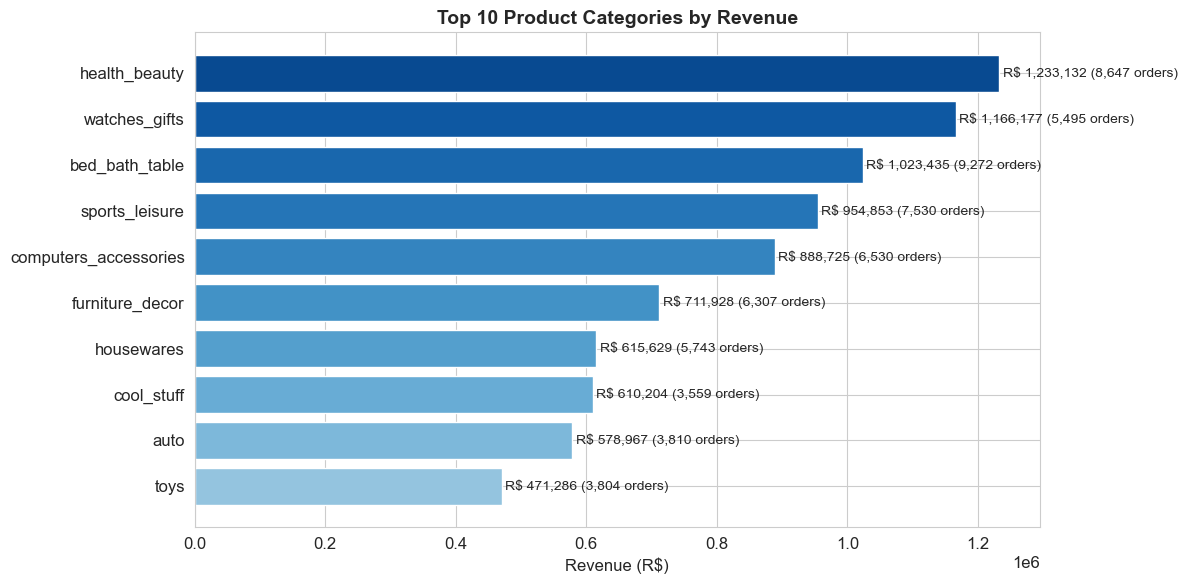

In [13]:
# Top 10 Categories by Revenue
cat_revenue = df.groupby('category').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique')
).sort_values('revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(cat_revenue)), cat_revenue['revenue'],
               color=plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_revenue)))[::-1])
ax.set_yticks(range(len(cat_revenue)))
ax.set_yticklabels(cat_revenue.index)
ax.set_xlabel('Revenue (R$)')
ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, (val, orders) in enumerate(zip(cat_revenue['revenue'], cat_revenue['orders'])):
    ax.text(val + 5000, i, f'R$ {val:,.0f} ({orders:,} orders)',
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [14]:
# Revenue Concentration (Pareto Analysis)
cat_all = df.groupby('category')['price'].sum().sort_values(ascending=False).reset_index()
cat_all['cumulative_pct'] = (cat_all['price'].cumsum() / cat_all['price'].sum() * 100)

n_80 = (cat_all['cumulative_pct'] <= 80).sum()
total_cats = len(cat_all)

print(f'{n_80} out of {total_cats} categories account for 80% of revenue')
print(f'That is {round(100*n_80/total_cats, 1)}% of categories driving 80% of revenue')

16 out of 73 categories account for 80% of revenue
That is 21.9% of categories driving 80% of revenue


## 9. Delivery & Operations Analysis

**Question:** How does delivery performance affect customer satisfaction?

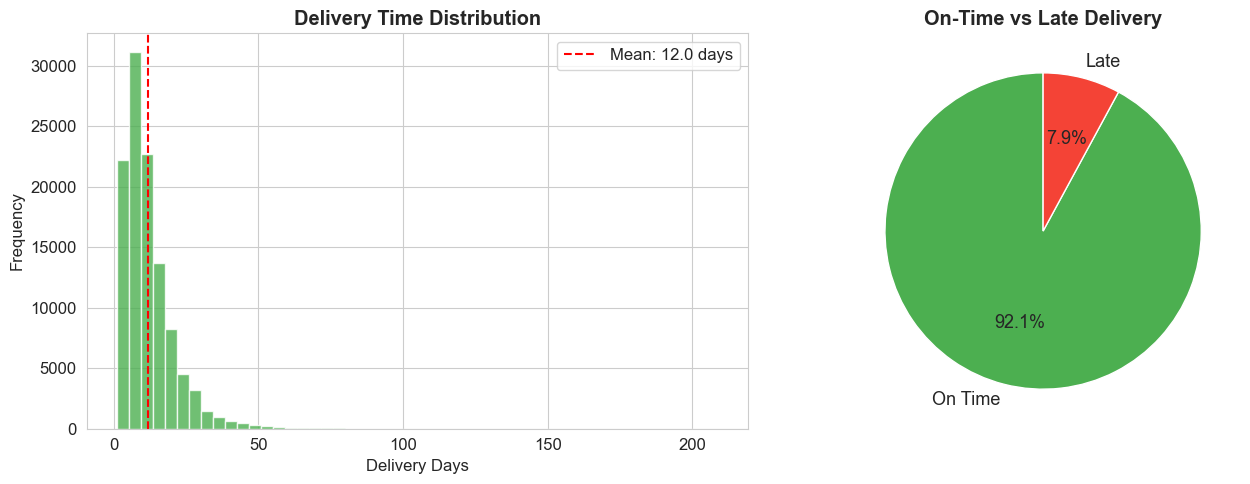

Late delivery rate: 7.9%
Avg delivery time: 12.0 days


In [15]:
# Delivery Time Distribution
delivery_valid = df[df['delivery_days'].notna() & (df['delivery_days'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delivery time histogram
axes[0].hist(delivery_valid['delivery_days'], bins=50, color='#4CAF50',
             edgecolor='white', alpha=0.8)
axes[0].axvline(delivery_valid['delivery_days'].mean(), color='red',
                linestyle='--', label=f'Mean: {delivery_valid["delivery_days"].mean():.1f} days')
axes[0].set_xlabel('Delivery Days')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Delivery Time Distribution', fontweight='bold')
axes[0].legend()

# On-time vs Late
late_counts = delivery_valid['is_late'].value_counts()
labels = ['On Time', 'Late']
colors = ['#4CAF50', '#F44336']
axes[1].pie(late_counts, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 13})
axes[1].set_title('On-Time vs Late Delivery', fontweight='bold')

plt.tight_layout()
plt.show()

late_pct = delivery_valid['is_late'].mean() * 100
print(f'Late delivery rate: {late_pct:.1f}%')
print(f'Avg delivery time: {delivery_valid["delivery_days"].mean():.1f} days')

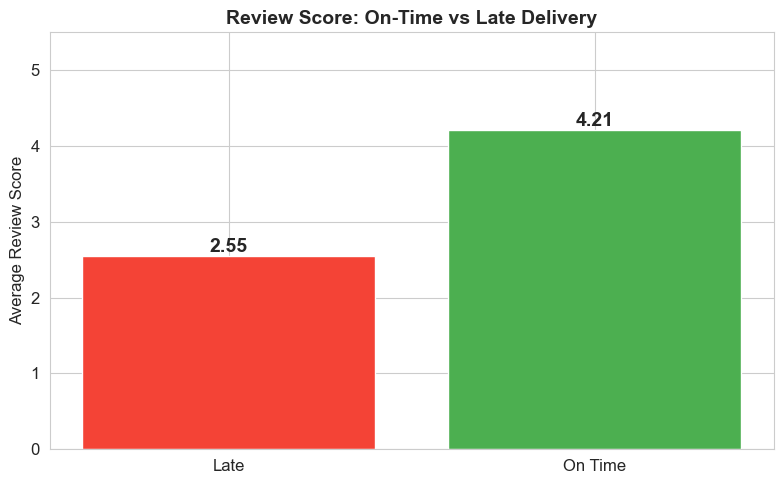

Average review scores:
  Late: 2.55 (n=8,560)
  On Time: 4.21 (n=101,445)


In [16]:
# Review Score vs Delivery Status
reviews_merged = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')
reviews_merged = reviews_merged[reviews_merged['delivery_days'].notna()]

reviews_merged['delivery_status'] = np.where(
    reviews_merged['is_late'] == 1, 'Late', 'On Time')

review_comparison = reviews_merged.groupby('delivery_status')['review_score'].agg(
    ['mean', 'count']
).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
colors = {'On Time': '#4CAF50', 'Late': '#F44336'}
bars = ax.bar(review_comparison.index, review_comparison['mean'],
              color=[colors[x] for x in review_comparison.index], edgecolor='white')

for bar, val in zip(bars, review_comparison['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=14, fontweight='bold')

ax.set_ylabel('Average Review Score')
ax.set_title('Review Score: On-Time vs Late Delivery', fontsize=14, fontweight='bold')
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

print('Average review scores:')
for status, row in review_comparison.iterrows():
    print(f'  {status}: {row["mean"]:.2f} (n={int(row["count"]):,})')

## 10. RFM Customer Segmentation

**RFM** segments customers based on three dimensions:
- **Recency (R):** Days since last purchase - lower is better
- **Frequency (F):** Number of orders - higher is better
- **Monetary (M):** Total spend - higher is better

**Methodology:** Score each dimension 1-5 using quantile-based binning (NTILE equivalent),
then map score combinations to named business segments.

In [17]:
# Calculate RFM metrics per customer
reference_date = df['order_purchase_timestamp'].max()

rfm = df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
).reset_index()

print(f'RFM calculated for {len(rfm):,} customers')
print(f'\nRFM Statistics:')
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

RFM calculated for 93,358 customers

RFM Statistics:
        recency  frequency  monetary
count  93358.00   93358.00  93358.00
mean     236.94       1.03    141.62
std      152.59       0.21    215.69
min        0.00       1.00      0.85
25%      113.00       1.00     47.65
50%      218.00       1.00     89.73
75%      345.00       1.00    154.74
max      713.00      15.00  13440.00


In [18]:
# Score R, F, M using quintiles (1-5)
# Recency: lower days = better = higher score
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
# Frequency & Monetary: higher = better = higher score
# Use rank method to handle ties in frequency (many customers have frequency=1)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Assign named segments based on score combinations
def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 1 and m >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost / Low Value'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print('Segment Distribution:')
seg_dist = rfm['segment'].value_counts()
for seg, count in seg_dist.items():
    pct = round(100 * count / len(rfm), 1)
    print(f'  {seg:25s}: {count:>6,} customers ({pct}%)')

Segment Distribution:
  At Risk                  : 22,230 customers (23.8%)
  Needs Attention          : 17,019 customers (18.2%)
  New Customers            : 14,984 customers (16.1%)
  Loyal Customers          : 13,689 customers (14.7%)
  Potential Loyalists      : 12,509 customers (13.4%)
  Lost / Low Value         :  6,478 customers (6.9%)
  Champions                :  6,449 customers (6.9%)


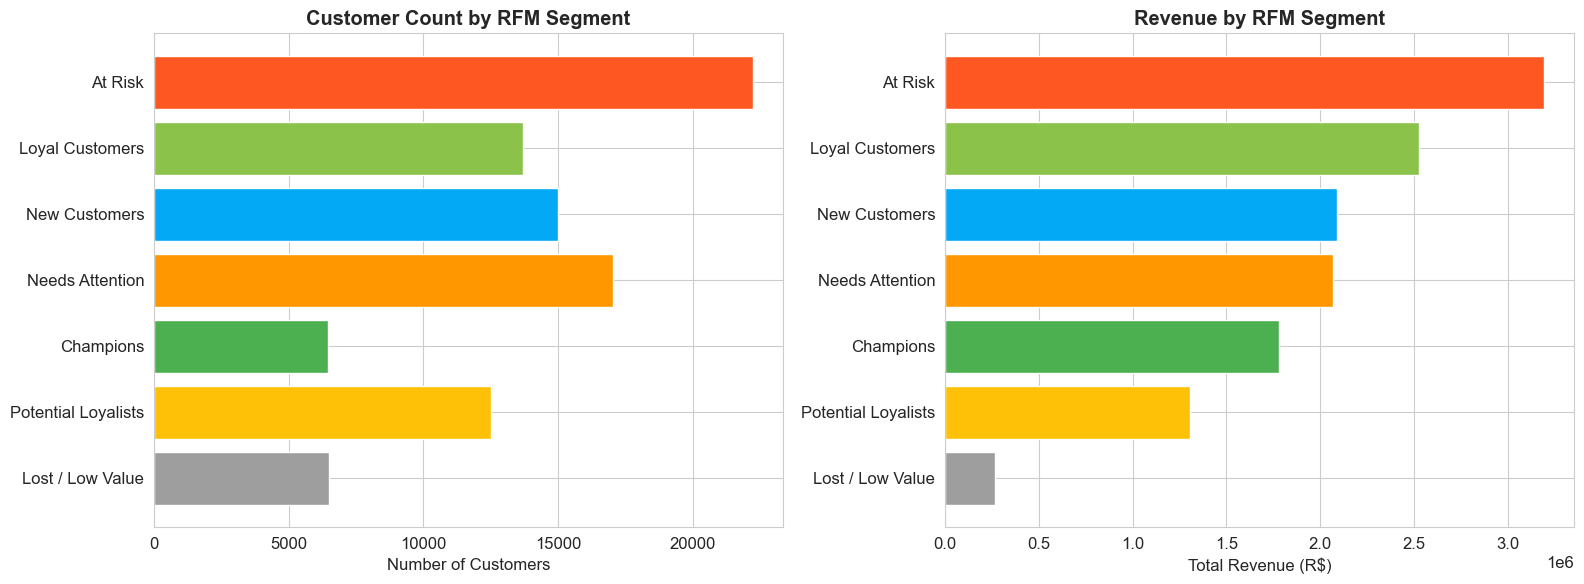

In [19]:
# RFM Segment Visualization
seg_summary = rfm.groupby('segment').agg(
    count=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).sort_values('total_revenue', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Customer count by segment
colors_map = {
    'Champions': '#4CAF50', 'Loyal Customers': '#8BC34A',
    'Potential Loyalists': '#FFC107', 'New Customers': '#03A9F4',
    'Needs Attention': '#FF9800', 'At Risk': '#FF5722',
    'Lost / Low Value': '#9E9E9E'
}
bar_colors = [colors_map.get(s, '#607D8B') for s in seg_summary.index]

axes[0].barh(range(len(seg_summary)), seg_summary['count'], color=bar_colors)
axes[0].set_yticks(range(len(seg_summary)))
axes[0].set_yticklabels(seg_summary.index)
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Customer Count by RFM Segment', fontweight='bold')

# Revenue by segment
axes[1].barh(range(len(seg_summary)), seg_summary['total_revenue'], color=bar_colors)
axes[1].set_yticks(range(len(seg_summary)))
axes[1].set_yticklabels(seg_summary.index)
axes[1].set_xlabel('Total Revenue (R$)')
axes[1].set_title('Revenue by RFM Segment', fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Cohort & Retention Analysis

**Methodology:**
1. Assign each customer a **cohort month** (month of first purchase)
2. Track subsequent orders and calculate **cohort index** (months since first purchase)
3. **Retention %** = active customers in period N / initial cohort size * 100

In [20]:
# Build Cohort Analysis
# Step 1: Determine each customer's cohort (first purchase month)
customer_cohort = df.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
customer_cohort.columns = ['customer_unique_id', 'first_purchase']
customer_cohort['cohort_month'] = customer_cohort['first_purchase'].dt.to_period('M')

# Step 2: Merge cohort info back and compute cohort index
df_cohort = df[['customer_unique_id', 'order_id', 'order_purchase_timestamp']].drop_duplicates(subset='order_id')
df_cohort = df_cohort.merge(customer_cohort[['customer_unique_id', 'cohort_month']], on='customer_unique_id')
df_cohort['order_period'] = df_cohort['order_purchase_timestamp'].dt.to_period('M')
df_cohort['cohort_index'] = (df_cohort['order_period'] - df_cohort['cohort_month']).apply(lambda x: x.n)

# Step 3: Count active customers per cohort per period
cohort_data = df_cohort.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_data.columns = ['cohort_month', 'cohort_index', 'active_customers']

# Step 4: Get cohort sizes and calculate retention
cohort_sizes = cohort_data[cohort_data['cohort_index'] == 0][['cohort_month', 'active_customers']]
cohort_sizes.columns = ['cohort_month', 'cohort_size']

cohort_data = cohort_data.merge(cohort_sizes, on='cohort_month')
cohort_data['retention_pct'] = (cohort_data['active_customers'] / cohort_data['cohort_size'] * 100).round(2)

# Pivot for heatmap (only first 12 months, only cohorts with enough data)
pivot = cohort_data[cohort_data['cohort_index'] <= 12].pivot_table(
    index='cohort_month', columns='cohort_index', values='retention_pct')

# Filter to cohorts that have at least 3 months of data
pivot = pivot.dropna(thresh=3)

print(f'Cohorts analyzed: {len(pivot)}')
print(f'Max cohort index: {cohort_data["cohort_index"].max()} months')

Cohorts analyzed: 19
Max cohort index: 20 months


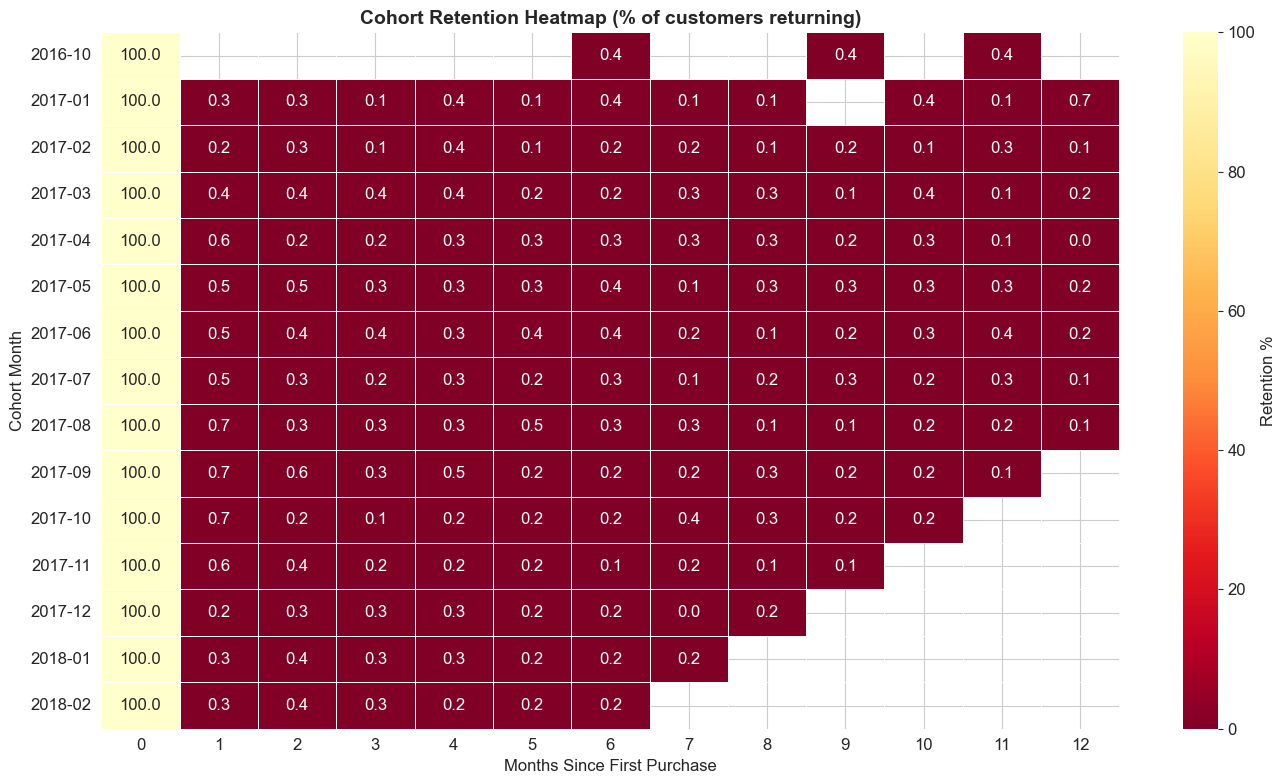

Average Retention by Month After First Purchase:
  Month 1: 0.5%
  Month 2: 0.3%
  Month 3: 0.2%
  Month 4: 0.3%
  Month 5: 0.2%
  Month 6: 0.3%
  Month 7: 0.2%
  Month 8: 0.2%
  Month 9: 0.2%
  Month 10: 0.3%
  Month 11: 0.2%
  Month 12: 0.2%


In [21]:
# Cohort Retention Heatmap
fig, ax = plt.subplots(figsize=(14, 8))

# Only show cohorts with enough data points
display_pivot = pivot.iloc[:15]  # Show up to 15 cohorts for readability

sns.heatmap(display_pivot, annot=True, fmt='.1f', cmap='YlOrRd_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            cbar_kws={'label': 'Retention %'})

ax.set_title('Cohort Retention Heatmap (% of customers returning)', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort Month')
ax.set_yticklabels([str(x) for x in display_pivot.index], rotation=0)

plt.tight_layout()
plt.show()

# Average retention by month
avg_retention = pivot.mean()
print('Average Retention by Month After First Purchase:')
for month, ret in avg_retention.items():
    if month > 0 and not pd.isna(ret):
        print(f'  Month {int(month)}: {ret:.1f}%')

## 12. Key Findings

### Revenue
- Total revenue of R$ 13.59M across ~96K delivered orders
- Revenue showed strong growth from late 2016 through late 2017, with stabilization in 2018
- Average Order Value (AOV) of approximately R$ 138, with high variance

### Customers
- 96,096 unique customers, but only ~3.1% are repeat buyers
- The overwhelming majority (96.9%) made only one purchase
- Repeat customers contribute a disproportionately higher average spend per customer

### Product & Category
- Top categories (health_beauty, watches_gifts, bed_bath_table) account for a large share of revenue
- Revenue is concentrated: a small number of categories drive the majority of sales (Pareto pattern)

### Operations
- Late deliveries have a measurably lower average review score compared to on-time deliveries
- Delivery performance varies significantly by customer state

### RFM & Retention
- Most customers fall into 'New Customers' or 'Lost / Low Value' segments (expected with 3% repeat rate)
- Cohort retention drops sharply after the first month
- Very few customers return to make a second purchase

## 13. Business Recommendations

| # | Finding | Recommendation |
|---|---------|---------------|
| 1 | Only 3.1% of customers are repeat buyers | Launch targeted re-engagement campaigns (email, push) for first-time buyers within 30 days of purchase |
| 2 | Top 10 categories drive majority of revenue | Prioritize inventory, marketing spend, and seller recruitment in high-revenue categories |
| 3 | Late deliveries correlate with lower review scores | Improve logistics in states with highest late delivery rates; set more realistic estimated delivery dates |
| 4 | Large 'Lost / Low Value' RFM segment | Design win-back campaigns with personalized discounts for at-risk and lapsed customers |
| 5 | Cohort retention drops sharply after Month 0 | Implement post-purchase engagement (loyalty program, cross-sell recommendations) to drive second purchase |

---
*Analysis by Vedant Bhavsar*